=== VISUALIZACIÓN DEL CUBO DE AGUA CON SAL ===
Cargando archivo: water_cube_trajectory.pdb
100 iones añadidos exitosamente. Guardado en 'water_with_salt.pdb'
Archivo cargado exitosamente: 1600 átomos encontrados

Creando visualizaciones...
Creando visualización interactiva...


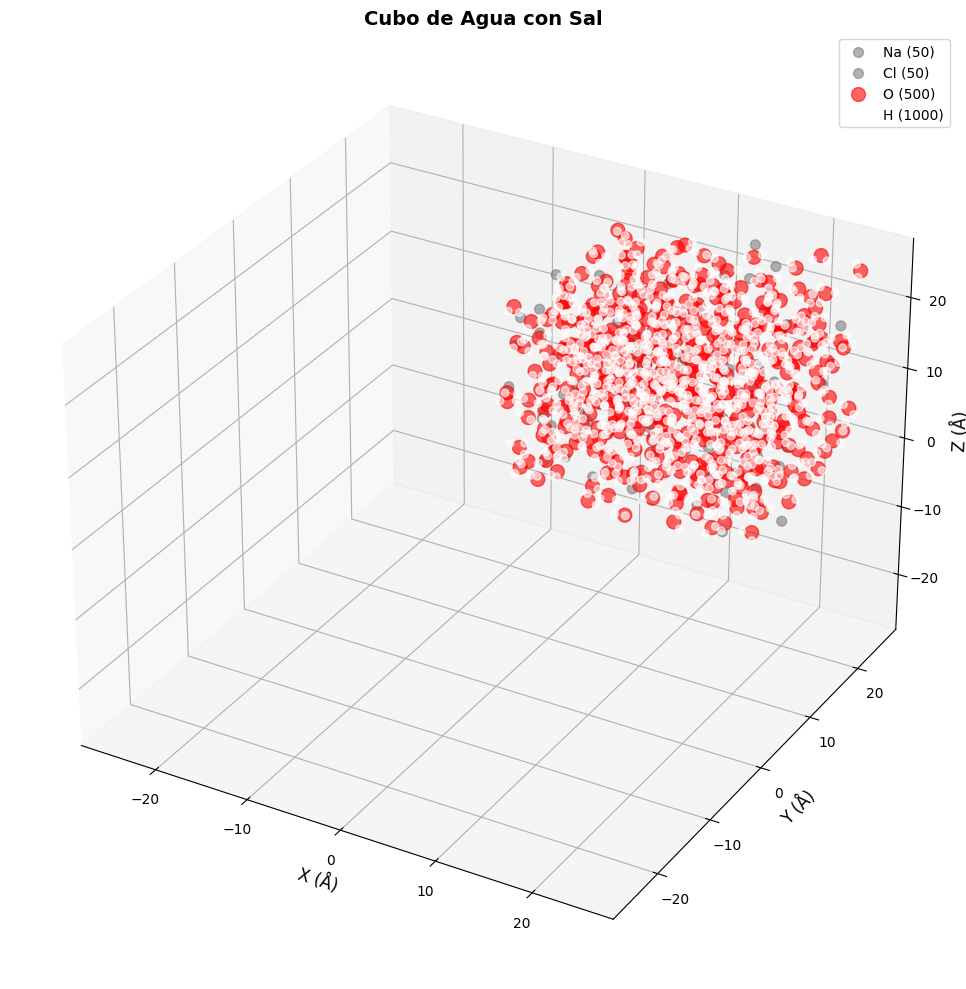

Visualización interactiva creada. Ejecuta 'viewer.show()' para mostrarla.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import py3Dmol
import os

def parse_pdb_file(filename):
    """
    Parsea el archivo PDB y extrae las coordenadas de los átomos
    """
    atoms = []
    coordinates = []
    
    try:
        with open(filename, 'r') as file:
            for line in file:
                if line.startswith('HETATM') or line.startswith('ATOM'):
                    atom_type = line[76:78].strip()
                    x = float(line[30:38])
                    y = float(line[38:46])
                    z = float(line[46:54])
                    
                    atoms.append(atom_type)
                    coordinates.append([x, y, z])
                    
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo {filename}")
        return None, None
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return None, None
    
    return atoms, np.array(coordinates)

def add_salt_to_pdb(input_filename, output_filename, num_pairs=50):
    """
    Añade iones de Na+ y Cl- al archivo PDB existente.
    
    Parameters:
    - input_filename: archivo PDB original (agua).
    - output_filename: nuevo archivo PDB con sal añadida.
    - num_pairs: número de pares Na+ y Cl- a agregar.
    """
    with open(input_filename, 'r') as f:
        lines = f.readlines()
    
    # Extraer coordenadas para estimar el volumen del cubo
    coords = []
    for line in lines:
        if line.startswith("HETATM") or line.startswith("ATOM"):
            x = float(line[30:38])
            y = float(line[38:46])
            z = float(line[46:54])
            coords.append([x, y, z])
    coords = np.array(coords)
    min_xyz = np.min(coords, axis=0)
    max_xyz = np.max(coords, axis=0)
    
    # Crear nuevos átomos Na y Cl
    new_lines = []
    atom_index = max([int(line[6:11]) for line in lines if line.startswith("ATOM") or line.startswith("HETATM")]) + 1

    for i in range(num_pairs):
        for ion_type, element in [("NA", "Na"), ("CL", "Cl")]:
            x = np.random.uniform(min_xyz[0], max_xyz[0])
            y = np.random.uniform(min_xyz[1], max_xyz[1])
            z = np.random.uniform(min_xyz[2], max_xyz[2])
            
            line = f"HETATM{atom_index:5d} {ion_type:<4} ION     1    {x:8.3f}{y:8.3f}{z:8.3f}  1.00  0.00          {element:>2}\n"
            new_lines.append(line)
            atom_index += 1
    
    # Guardar nuevo archivo
    with open(output_filename, 'w') as f_out:
        for line in lines:
            if line.startswith("END"):
                continue
            f_out.write(line)
        for line in new_lines:
            f_out.write(line)
        f_out.write("END\n")
    
    print(f"{2 * num_pairs} iones añadidos exitosamente. Guardado en '{output_filename}'")

def visualize_water_cube_matplotlib(atoms, coordinates, frame_title="Cubo de Agua con Sal"):
    """
    Visualiza el cubo de agua con sal usando matplotlib
    """
    if atoms is None or coordinates is None:
        return None
    
    # Configuración de colores
    color_map = {
        'O': 'red',
        'H': 'white',
        'NA': 'purple',
        'CL': 'teal',
        'HOH': 'red'
    }
    
    # Configuración de tamaños
    size_map = {
        'O': 100,
        'H': 30,
        'NA': 120,
        'CL': 120,
        'HOH': 100
    }
    
    # Crear figura 3D
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Separar átomos por tipo
    atom_coords = {}
    for atom_type in set(atoms):
        atom_coords[atom_type] = []
    
    for i, atom in enumerate(atoms):
        coord = coordinates[i]
        atom_coords[atom].append(coord)
    
    for atom_type, coords_list in atom_coords.items():
        coords_array = np.array(coords_list)
        ax.scatter(coords_array[:, 0], coords_array[:, 1], coords_array[:, 2],
                   c=color_map.get(atom_type, 'gray'),
                   s=size_map.get(atom_type, 50),
                   alpha=0.6,
                   label=f'{atom_type} ({len(coords_array)})')
        
    # Configurar ejes y título
    ax.set_xlabel('X (Å)', fontsize=12)
    ax.set_ylabel('Y (Å)', fontsize=12)
    ax.set_zlabel('Z (Å)', fontsize=12)
    ax.set_title(frame_title, fontsize=14, fontweight='bold')
    
    # Leyenda
    ax.legend()
    
    # Configurar límites iguales para todos los ejes
    all_coords = coordinates
    if len(all_coords) > 0:
        max_range = np.max(np.abs(all_coords)) * 1.1
        ax.set_xlim(-max_range, max_range)
        ax.set_ylim(-max_range, max_range)
        ax.set_zlim(-max_range, max_range)
    
    # Grid
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax

def visualize_water_cube_py3dmol(filename):
    """
    Visualiza el cubo de agua con sal usando py3Dmol directamente desde el archivo PDB
    """
    try:
        # Leer el archivo PDB
        with open(filename, 'r') as file:
            pdb_content = file.read()
        
        # Crear visualizador
        viewer = py3Dmol.view(width=800, height=600)
        
        # Agregar el modelo PDB
        viewer.addModel(pdb_content, 'pdb')
        
        # Configurar estilos
        viewer.setStyle({'elem': 'O'}, {'sphere': {'color': 'red', 'radius': 0.8}})
        viewer.setStyle({'elem': 'H'}, {'sphere': {'color': 'white', 'radius': 0.4}})
        viewer.setStyle({'elem': 'Na'}, {'sphere': {'color': 'purple', 'radius': 1.0}})
        viewer.setStyle({'elem': 'Cl'}, {'sphere': {'color': 'teal', 'radius': 1.0}})
        
        # Agregar enlaces de agua
        viewer.addStyle({}, {'stick': {'radius': 0.1}})
        
        # Configurar visualización
        viewer.setBackgroundColor('white')
        viewer.zoomTo()
        
        return viewer
        
    except Exception as e:
        print(f"Error en py3Dmol: {e}")
        return None

def main_visualization(pdb_filename="water_cube_trajectory.pdb", num_salt_pairs=50):
    """
    Función principal para visualizar el cubo de agua con sal
    """
    print("=== VISUALIZACIÓN DEL CUBO DE AGUA CON SAL ===")
    print(f"Cargando archivo: {pdb_filename}")
    
    # Añadir sal al archivo PDB
    output_pdb = "water_with_salt.pdb"
    add_salt_to_pdb(pdb_filename, output_pdb, num_pairs=num_salt_pairs)
    
    # Parsear archivo PDB con sal
    atoms, coordinates = parse_pdb_file(output_pdb)
    
    if atoms is None:
        print("No se pudo cargar el archivo. Asegúrate de que existe y está en el directorio correcto.")
        return None
    
    print(f"Archivo cargado exitosamente: {len(atoms)} átomos encontrados")
    
    # Crear visualizaciones
    print("\nCreando visualizaciones...")
    
    # Visualización 3D principal con matplotlib
    fig1, ax1 = visualize_water_cube_matplotlib(atoms, coordinates)
    
    # Visualización interactiva con py3Dmol
    print("Creando visualización interactiva...")
    viewer = visualize_water_cube_py3dmol(output_pdb)
    
    # Mostrar gráficos
    plt.show()
    
    if viewer:
        print("Visualización interactiva creada. Ejecuta 'viewer.show()' para mostrarla.")
        return fig1, viewer
    else:
        return fig1, None

# Ejecutar visualización
# Asegúrate de que 'water_cube_trajectory.pdb' esté en el directorio actual
fig, viewer = main_visualization("water_cube_trajectory.pdb", num_salt_pairs=50)

# Para mostrar la visualización interactiva en Jupyter Notebook, ejecuta:
# viewer.show()
